# Модель оценки стоимости автомобилей
---

## Описание 

###  Общая информация

- заказчик: **AutoValue AI** - стартап, который внедряет модель мгновенного выкупа автомобилей на рынке подержанных автомобилей
- Как должнн работать сервис:
    - Клиент заполняет анкету в приложении.
    - Алгоритм за одну секунду рассчитывает стоимость.
    - Если клиента устраивает цена, он приезжает в ближайший офис продаж, где техник за 15 минут подтверждает состояние авто, а клиент мгновенно получает деньги на счёт.
- доступные данные -- информация о 10 000 прошлых сделок, которые эксперты провели вручную

## Бизнес-задача
Разработать автоматизированную систему оценки стоимости автомобилей, основанную на накопленном специалистами опыте. 
Внедрение модели позволит: 
- увеличить скорость оценки -- это позволит удержать больше клиентов
- повысить качество оценки -- это снизит риск убытков
- повысит пропускную способность сервиса (обслуживание большего количества клиентов в единицу времени) -- это способствует масштабированию бизнеса  

## Цель
- разработать модель машинного обучения для оценки автомобилей, учитывающую нелинейные связи между признаками

## Задачи
- определить наиболее эффективную библиотеку градиентного бустинга: LightGBM, CatBoost, XGBoost 
- минимизировать финансовые риски
- обеспечить прозрачность работы модели

## ML задача

Вид задачи:
- обучение с учителем
- подтип: регрессия 

Целевая переменная:
- **price_rub** -- рыночная стоимость автомобиля в рублях (для бизнеса это реальная сумма сделки, которую нужно предсказать).

Особенности:
- нелинейные свзяи между признаками
- отдельные датасеты под train и test

## Бизнес метрики
1. **Доля опасных переплат (Overpricing Rate)** - это процент случаев, когда модель предсказала цену на 20% выше реальной. Каждая такая машина — это прямой убыток. Покупая машину слишком дорого, компания не сможет перепродать с прибылью.

    Логика расчёта:

    - $Error Ratio = \frac{Предсказание−Реальность}{Реальность}$ 
    - если зачение > 0.2 - помечаем этот случай как «опасный».
    - Делим количество таких «опасных» случаев на общее количество машин в выборке

2. **Упущенная выгода (Underpricing Loss)** -  суммарная разница в случаях, когда модель занизила цену более чем на 20%. В таких случаях клиент просто развернётся и уйдёт к конкурентам. Компания теряет долю рынка.

    Логика расчета:
    - Находим все случаи, где наше предложение было ниже реальности более чем на 20% ($Error Ratio < -0.20$)
    - Для этих случаев вычисляем разницу между реальной ценой и нашим прогнозом. Это и есть сумма, которую недоплатили.
    - Суммируем все эти разницы




---
## 1. Настройка проекта и загрузка данных

In [164]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from phik import phik_matrix
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [81]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

In [82]:
# настройки визуалиции 
plt.rcParams["figure.figsize"] = (12, 8)

In [83]:
# пути для скачивания данных
data_path_train = 'https://code.s3.yandex.net/datasets/ds_s16_train_data.csv'
data_path_test = 'https://code.s3.yandex.net/datasets/ds_s16_test_data.csv'

In [84]:
df_train = pd.read_csv(data_path_train)
display(df_train.info(), df_train.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           8000 non-null   int64  
 1   mileage_kmpl        8000 non-null   float64
 2   engine_cc           8000 non-null   int64  
 3   fuel_type           8000 non-null   object 
 4   owner_count         8000 non-null   int64  
 5   brand               8000 non-null   object 
 6   transmission        8000 non-null   object 
 7   color               8000 non-null   object 
 8   service_history     8000 non-null   object 
 9   accidents_reported  8000 non-null   int64  
 10  insurance_valid     8000 non-null   object 
 11  price_rub           8000 non-null   int64  
 12  region              8000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 812.6+ KB


None

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


In [85]:
df_test = pd.read_csv(data_path_test)
display(df_test.info(), df_test.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           2000 non-null   int64  
 1   mileage_kmpl        2000 non-null   float64
 2   engine_cc           2000 non-null   int64  
 3   fuel_type           2000 non-null   object 
 4   owner_count         2000 non-null   int64  
 5   brand               2000 non-null   object 
 6   transmission        2000 non-null   object 
 7   color               2000 non-null   object 
 8   service_history     2000 non-null   object 
 9   accidents_reported  2000 non-null   int64  
 10  insurance_valid     2000 non-null   object 
 11  price_rub           2000 non-null   int64  
 12  region              2000 non-null   object 
dtypes: float64(1), int64(5), object(7)
memory usage: 203.2+ KB


None

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2015,12.09,5000,Diesel,1,Nissan,Automatic,White,Full,2,No,1213351,Москва
1,2016,14.03,800,Petrol,4,Chevrolet,Manual,White,Partial,0,Yes,586881,Дальний Восток
2,2005,20.40,2000,Petrol,1,Kia,Manual,Blue,Full,2,Yes,650752,Сибирь
3,1996,25.09,800,Diesel,3,Volkswagen,Manual,Silver,Full,0,Yes,320452,Урал
4,1995,19.25,5000,Diesel,5,Hyundai,Automatic,Black,Partial,0,No,694911,СПб


Итог:
- данные для train и test считаны корректно
- явных пропусков нет
- типы данных соответсвуют описанию

---
## 2. EDA (Экспресс-анализ данных)
Бизнесу важно понимать природу данных.
- Изучите распределение целевой переменной price_rub.
- Проверьте корреляции.

### Общая информация

In [86]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'category']
NUM_COLS_TYPES = [np.number]

In [87]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

In [88]:
get_base_df_info(name='Train dataset', df=df_train)

Общая информация о датафрейме Train dataset


,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,price_rub,region
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,242073,Урал
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,426029,Москва
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,727050,Юг
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,753168,Дальний Восток
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,733390,Сибирь


,Метрика,Значение
0,Строк,8000.0
1,Колонок,13.0
2,"Явных дубликатов, %",0.0
3,Категориальных колонок,7.0
4,Числовых колонок,6.0


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
price_rub,int64,0,0.0,7929
mileage_kmpl,float64,0,0.0,2108
make_year,int64,0,0.0,29
engine_cc,int64,0,0.0,10
brand,object,0,0.0,10
color,object,0,0.0,6
accidents_reported,int64,0,0.0,6
region,object,0,0.0,6
owner_count,int64,0,0.0,5
fuel_type,object,0,0.0,3


Типы колонок


,Категориальные колонки,Числовые колонки
0,fuel_type,make_year
1,brand,mileage_kmpl
2,transmission,engine_cc
3,color,owner_count
4,service_history,accidents_reported
5,insurance_valid,price_rub
6,region,NaN


--------------------------------------------------


Анализ:
- явных дублей и пропусков нет
- 7 категориальных и 5 числовых признаков + таргет числовой

### Анализ распределений 

In [89]:
cat_cols, num_cols = get_cat_num_cols(df=df_train)

In [90]:
target_col = 'price_rub'
cat_cols_feat = cat_cols.copy()
num_cols_feat = [col for col in num_cols if col != target_col]

In [91]:
def plot_hist_box(
    df: pd.DataFrame, 
    feature_name: str,
    x_label: str = 'значение',
    bins=30
):
    """Гистограмма + ящик с усами для анализа распределений количественных данных"""
    fig, axes = plt.subplots(nrows=2, ncols=1)
    axes[0].grid(True)
    axes[1].grid(True)
    sns.histplot(data=df, x=feature_name, stat='density', ax=axes[0], bins=bins)
    sns.boxplot(data=df, x=feature_name, orient="h", ax=axes[1])
    axes[0].set_title(f'Распределение {feature_name}')
    axes[0].set_ylabel('плотность')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(feature_name)
    plt.show()

#### Таргет

In [92]:
df_train[target_col].describe()

count    8.000000e+03
mean     6.836479e+05
std      2.649235e+05
min      9.500000e+04
25%      4.938570e+05
50%      6.638660e+05
75%      8.550560e+05
max      1.676525e+06
Name: price_rub, dtype: float64

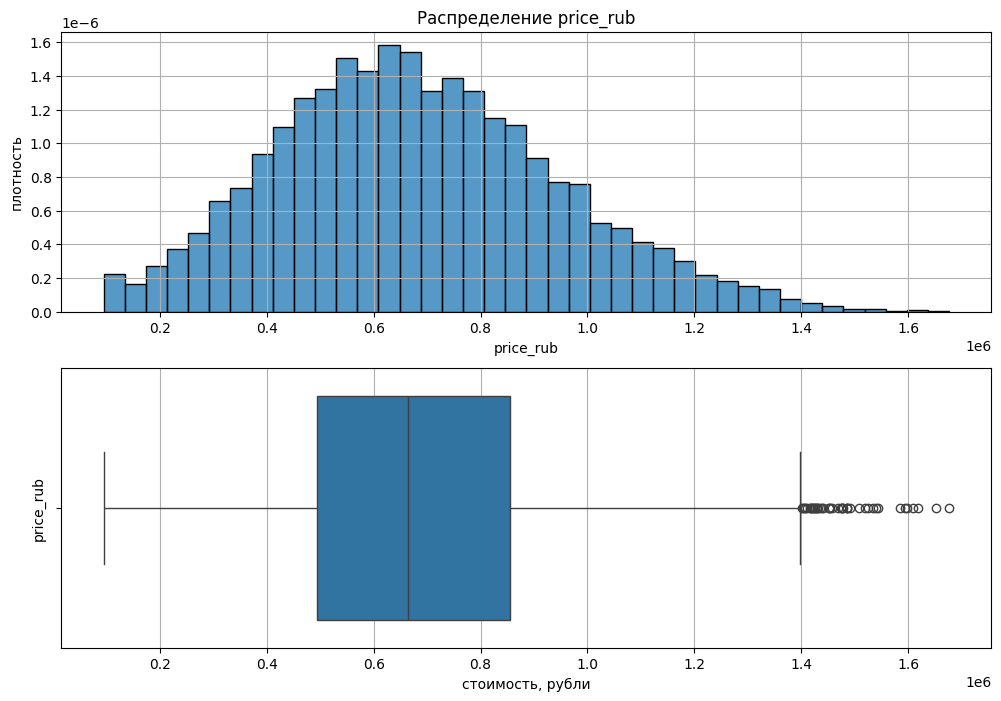

In [93]:
plot_hist_box(df=df_train, feature_name=target_col, x_label='стоимость, рубли', bins=40)

In [94]:
df_train[target_col].min()

np.int64(95000)

Анализ:
- распределение таргета симметричное (можно приблизить усеченным слева нормальным распределением)
- в правом хвосте распределения есть малочисленные выбросы 
- на левой границе можно отметить пороговое значение 95000 (подозрительно ровная сумма!), ниже которого значений нет. Возможно, это фиксированная нижняя цена для всех покупаемых на перепродажу авто. 

#### Количественные признаки

In [95]:
df_train[num_cols_feat].describe()

,make_year,mileage_kmpl,engine_cc,owner_count,accidents_reported
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,2009.221250,17.946343,2289.687500,3.001125,0.487875
std,8.388703,5.015565,1289.812139,1.419199,0.693839
min,1995.000000,5.000000,800.000000,1.000000,0.000000
25%,2002.000000,14.530000,1200.000000,2.000000,0.000000
50%,2009.000000,17.970000,2000.000000,3.000000,0.000000
75%,2017.000000,21.350000,3000.000000,4.000000,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,5.000000


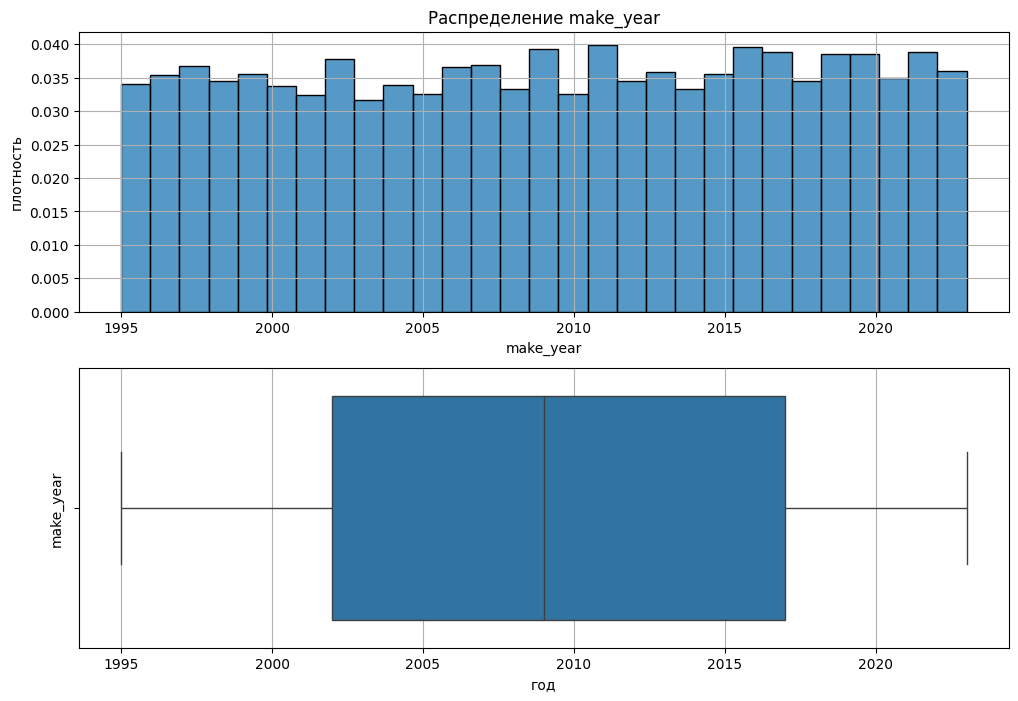

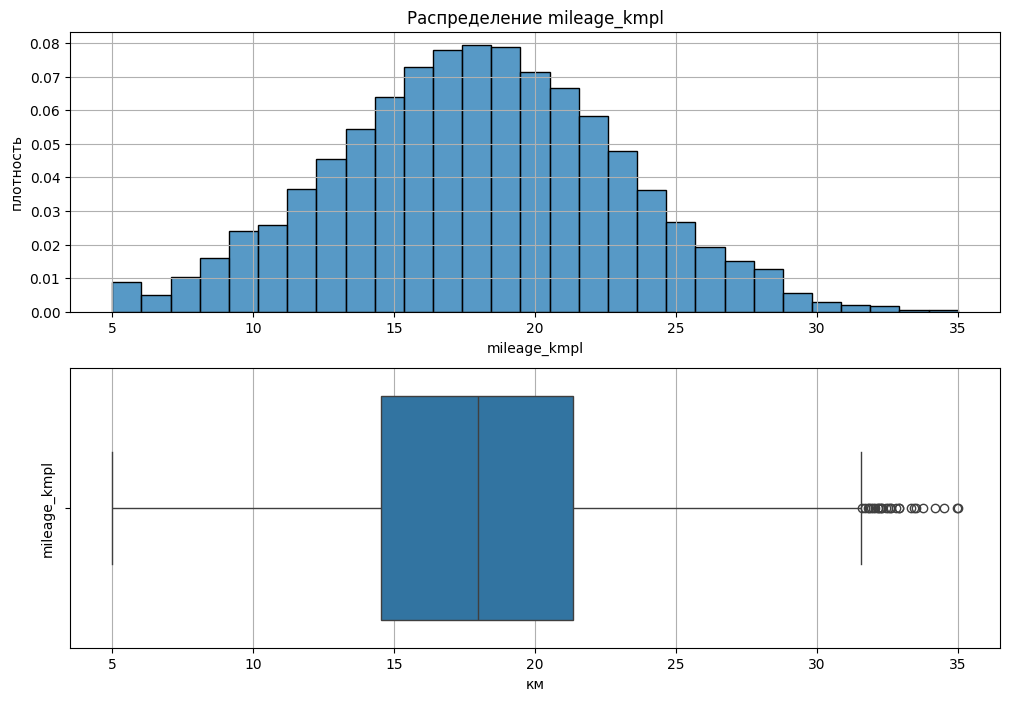

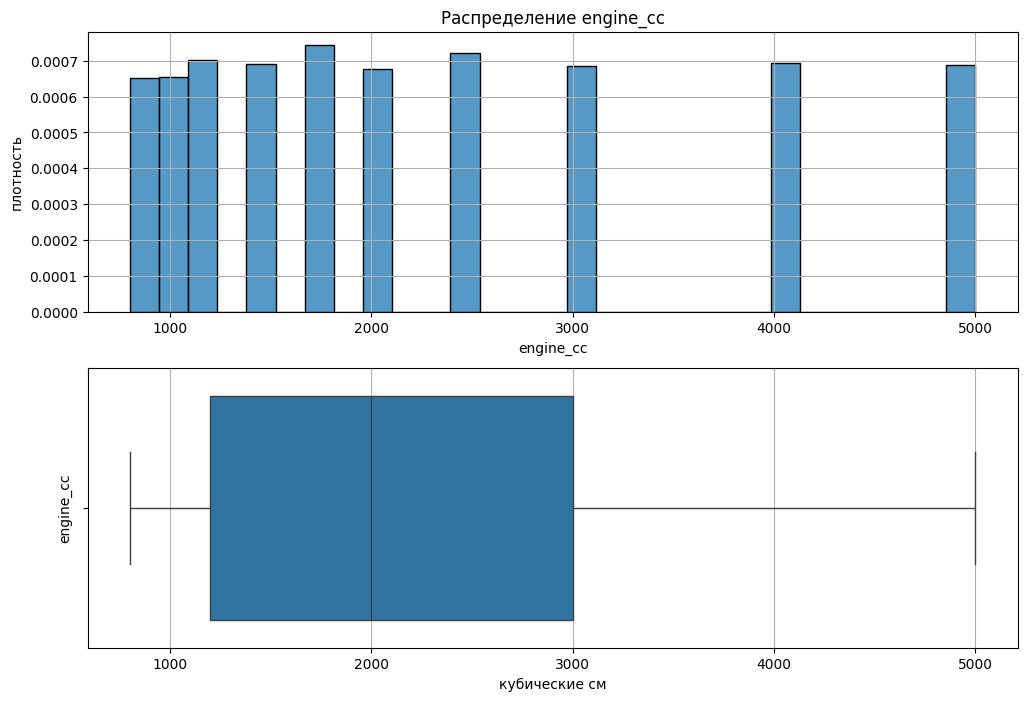

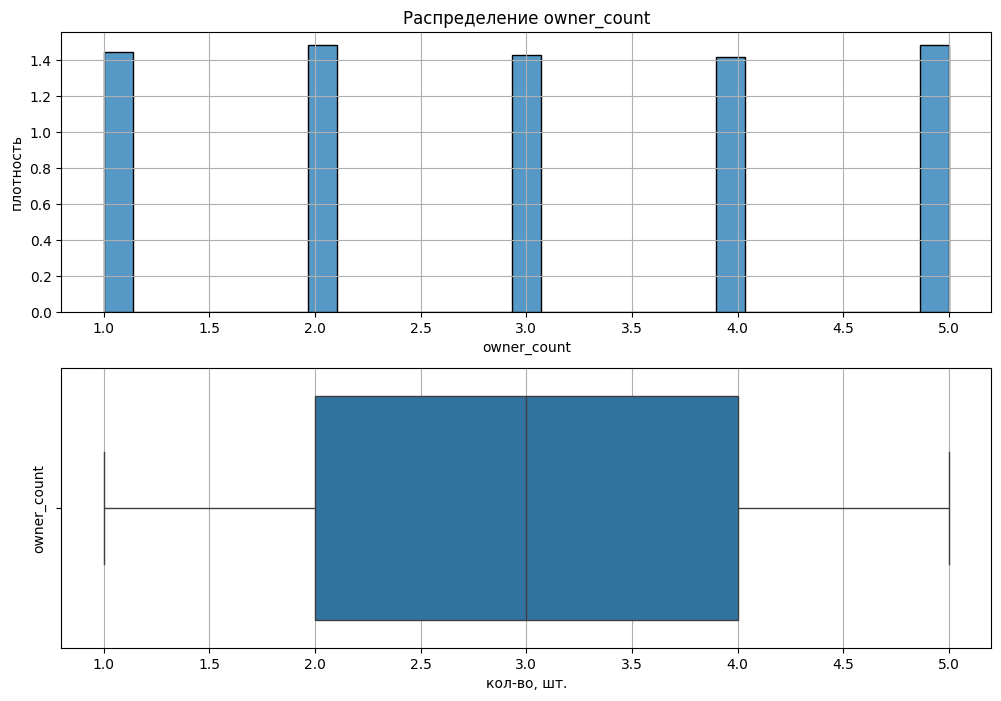

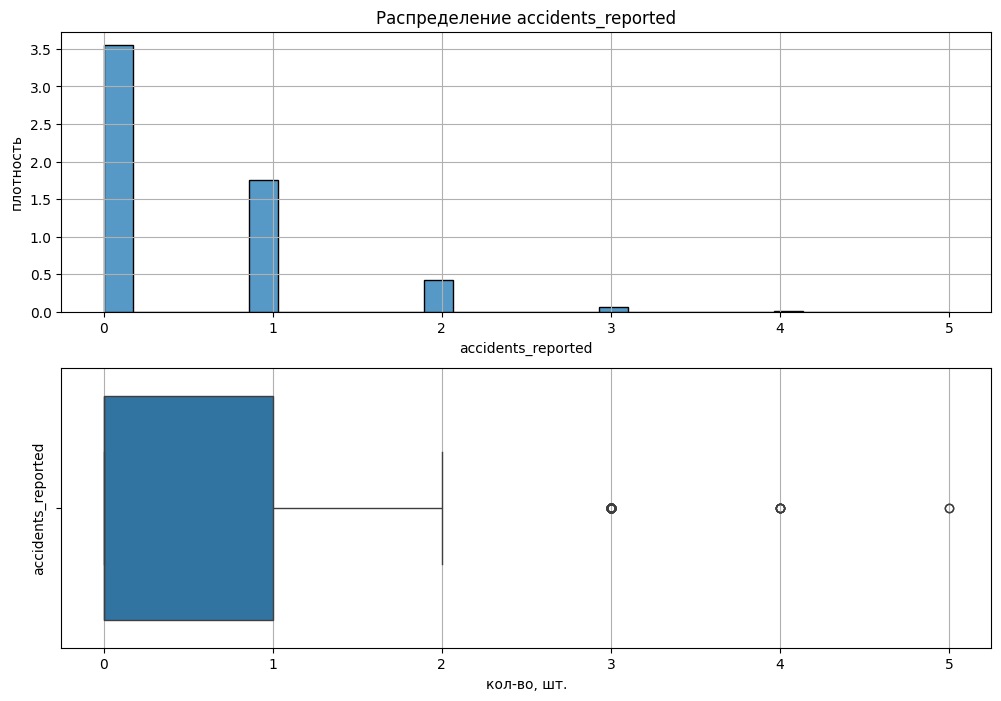

In [96]:
x_names = ['год', 'км', 'кубические см', 'кол-во, шт.', 'кол-во, шт.']
for col_name, x_name in zip(num_cols_feat, x_names):
    plot_hist_box(df=df_train, feature_name=col_name, x_label=x_name, bins=29)

Анализ:
- make_year	(Год выпуска) - распределение равномерное.
- mileage_kmpl	(Пробег (км)) - симметричное распределение с явной минимальной границей в 5.0км. Есть малочисленные экстремальные значения на правом хвосте
- engine_cc	(Объём двигателя (в кубических см)) - дискретный набор стандартных по объему двигателя значений. Среди дискретных значений распределение равномерное. Чаще встречаются двигателя объемом до 2000 куб. см.
- owner_count	(Количество владельцев по ПТС) - от 1 до 5 целые значения. Распределение равномерное
- accidents_reported	(Количество зафиксированных ДТП) - от 0 до 5 целые значения. Распределение экспоненциально убывает. Чтобы усилить связь большого кол-ва ДТП с целевую переменной, стоит рассмотреть преобразование возведения в степень.

#### Категориальные данные 

In [119]:
def plot_count_bars(
    df: pd.DataFrame, col_name: str
):
    """Столбчатые диаграммы распрелелений категориальных признаков"""
    counts = df[col_name].value_counts()
    freq_order = counts.index
    mean_value = counts.mean()

    ax = sns.countplot(data=df, x=col_name, order=freq_order)

    ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)

    # горизонтальная линия среднего значения
    plt.axhline(
        y=mean_value,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Среднее: {mean_value:.1f}",
    )

    plt.title(f"Распределение признака {col_name}")
    plt.ylabel("количество")
    plt.xticks(rotation=45)
    plt.legend()

    plt.ylim(top=plt.ylim()[1] * 1.05)

    plt.show()

In [120]:
df_train[cat_cols_feat].describe()

,fuel_type,brand,transmission,color,service_history,insurance_valid,region
count,8000,8000,8000,8000,8000,8000,8000
unique,3,10,2,6,3,2,6
top,Petrol,Nissan,Manual,White,Full,Yes,Юг
freq,3990,870,4812,1366,3985,6356,1408


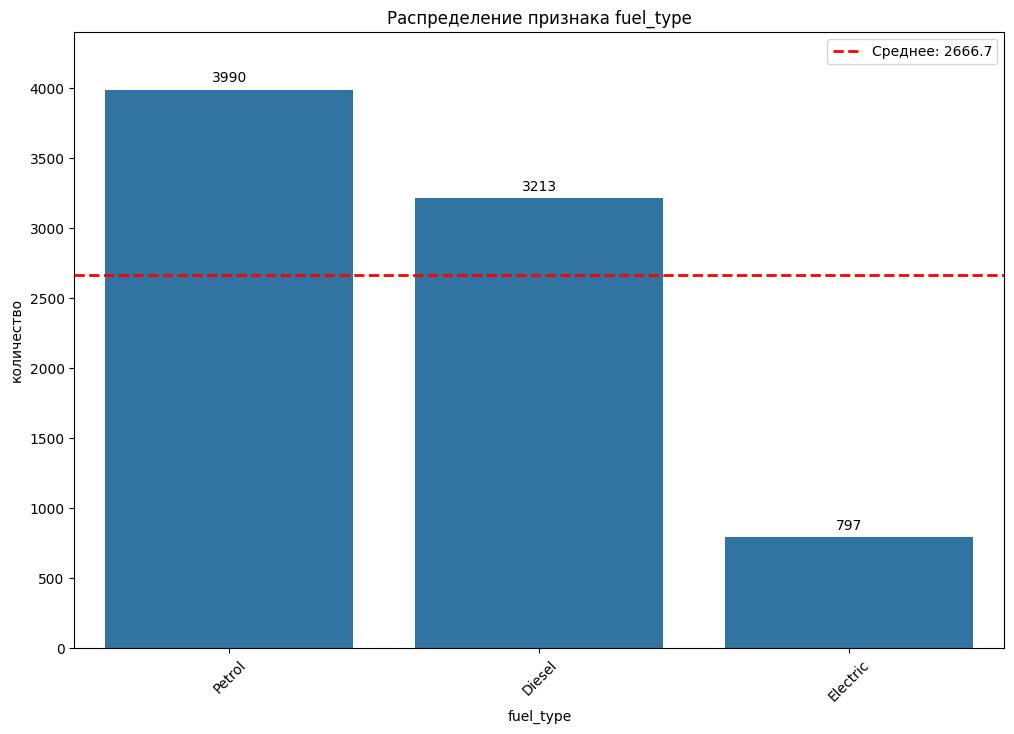

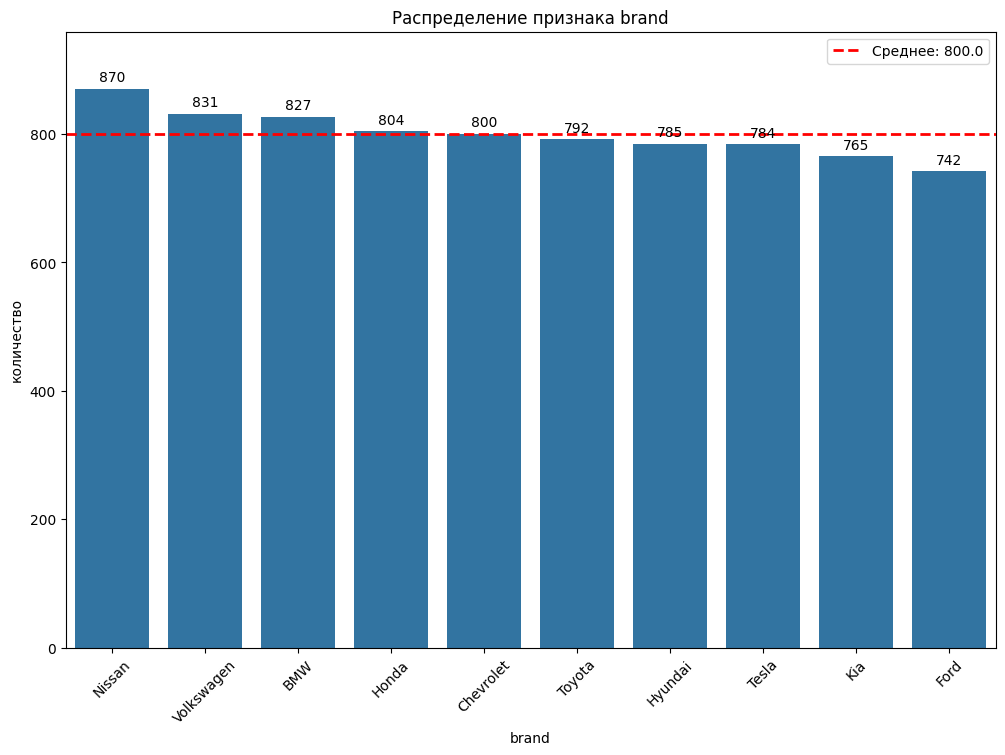

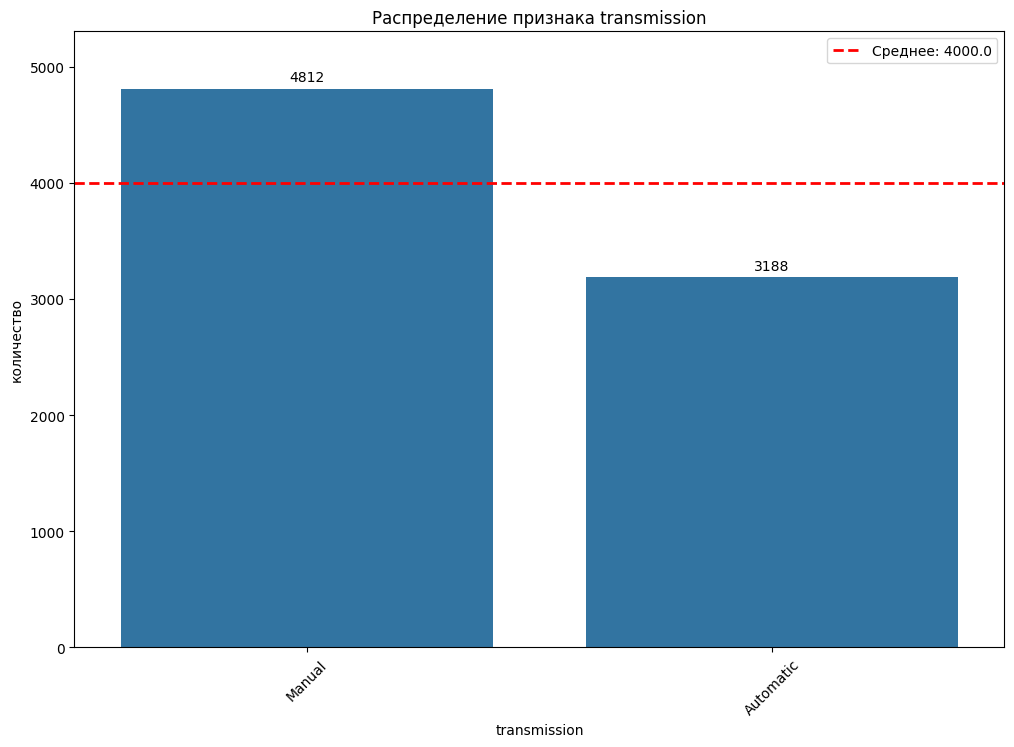

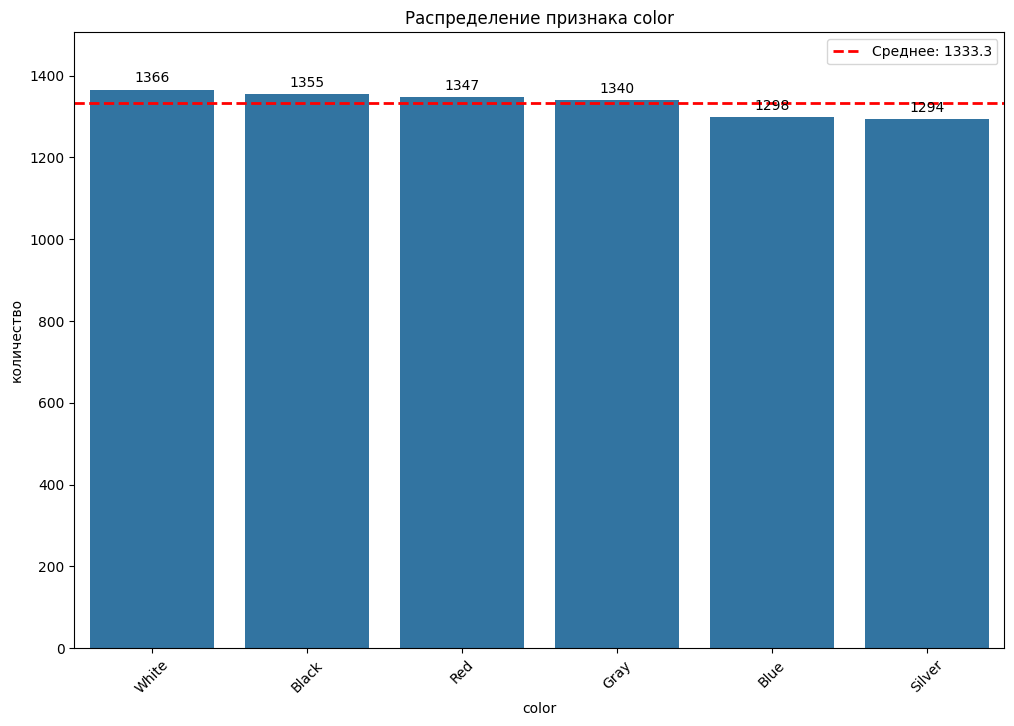

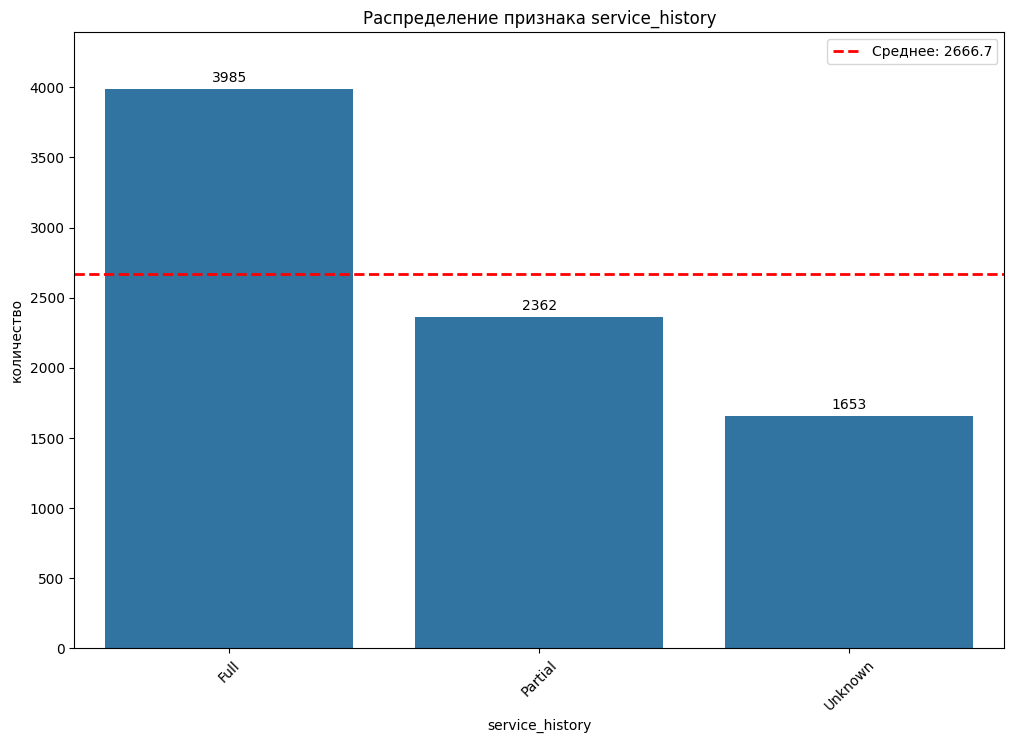

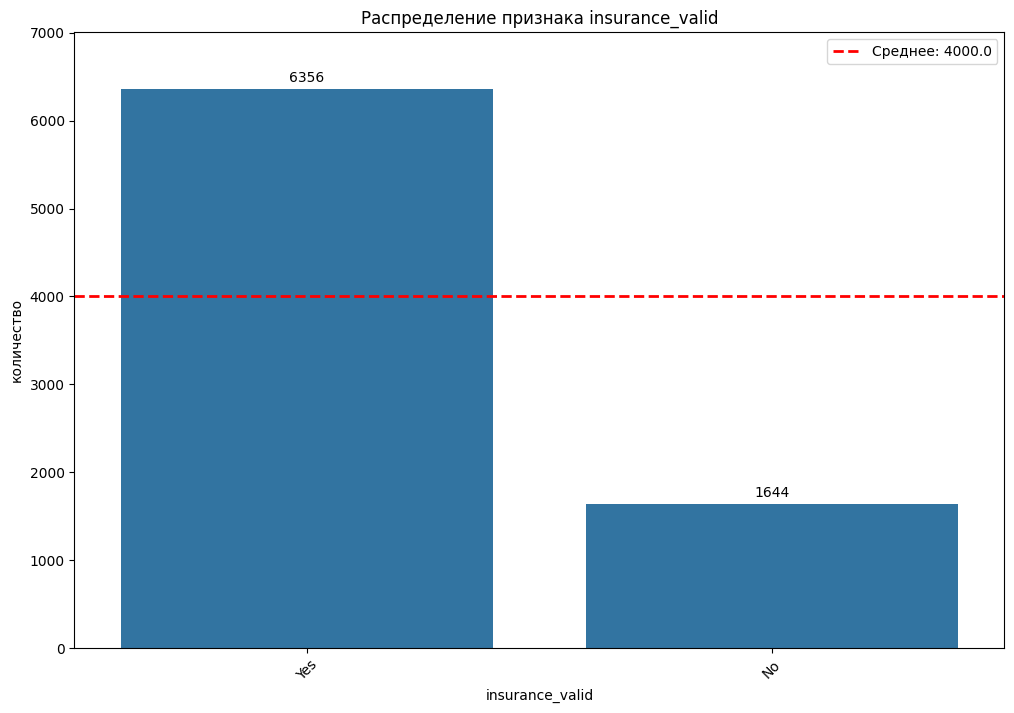

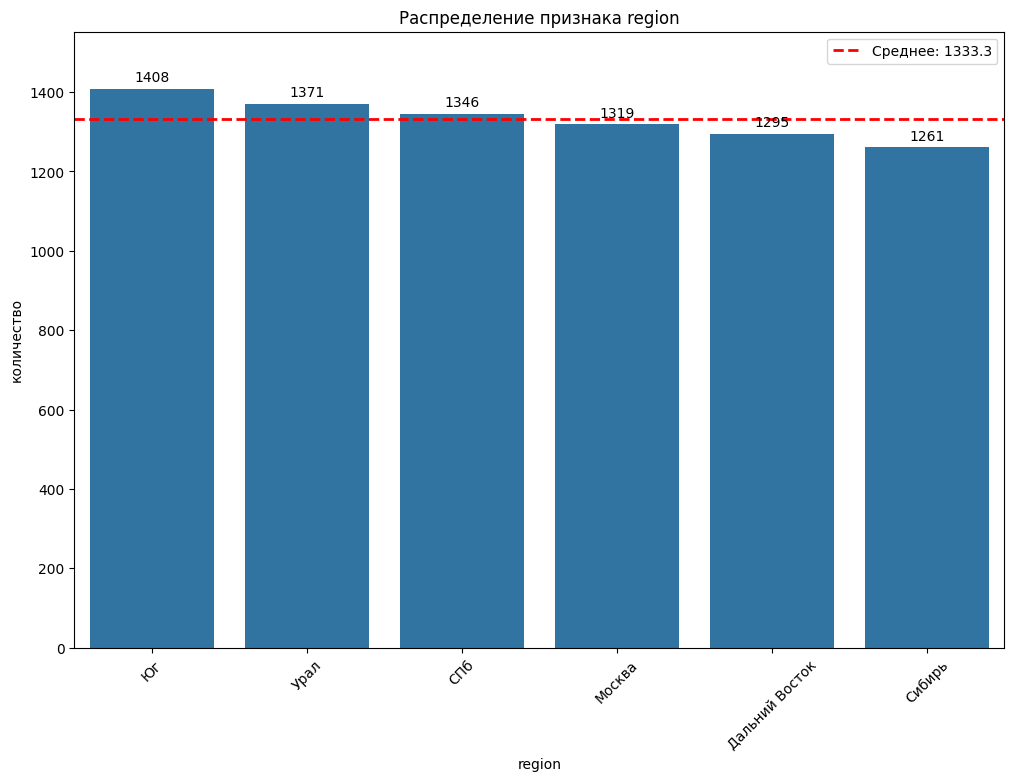

In [121]:
for name in cat_cols_feat:
    plot_count_bars(df=df_train, col_name=name)

Анализ:
- brand	(Марка автомобиля) - в лидерах Nissan, наименне пополярен Ford. По количеству все марки в пределах 10% около среднего.
- region (Макрорегион РФ, в котором продаётся автомобиль) - наиболее популярный ЮГ, наименее - Сибирь. Распределение в в пределах 10% около среднего. 
- color	(Цвет автомобиля) - распределение равномерное (черные и белые чаще встречаются, чем синие и серебрянные, но разница несущественная)
- insurance_valid	(Действительна ли страховка) - существенное преобладание авто с действующей на момент сделки страховки. Разница в 4 раза
- service_history	(Наличие сервисной книжки) - преобладают значения с полной историей, с частичной исторей меньше в ~1.5 раза, без истории меньше в ~2.5 раза
-  transmission	(Тип коробки передач) - механики в 1.5 раза больше, чем автомата
- fuel_type	(Тип топлива) - бензиновые двигателей на 20% больше, чем дизеля. Электрокары малочисленны - более чем в 4 раза меньше, чем остальных видов.

### Корреляционный анализ

In [123]:
def get_corr_matrix(
    data: pd.DataFrame, feat_cols: list[str], 
    num_cols: list[str]
):
    """Матрица корреляций"""
    corr_matrix = data[feat_cols].phik_matrix(
        interval_cols=num_cols if len(num_cols) > 0 else None,
        njobs=-1,
    )

    return corr_matrix

def plot_corr_matrix(corr_matrix):
    """Тепловая карта"""
    plt.figure(figsize=(14, 10)) 

    sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

    plt.title('Тепловая карта матрицы корреляций')
    plt.show()

def corr_with_target(corr_matrix, target_col_name):
    """Корреляция с таргетом"""
    return corr_matrix[target_col_name].sort_values(ascending=False)

In [127]:
corr_matrix = get_corr_matrix(
    data=df_train, 
    feat_cols=num_cols_feat + cat_cols_feat + [target_col], 
    num_cols=num_cols_feat + [target_col]
)

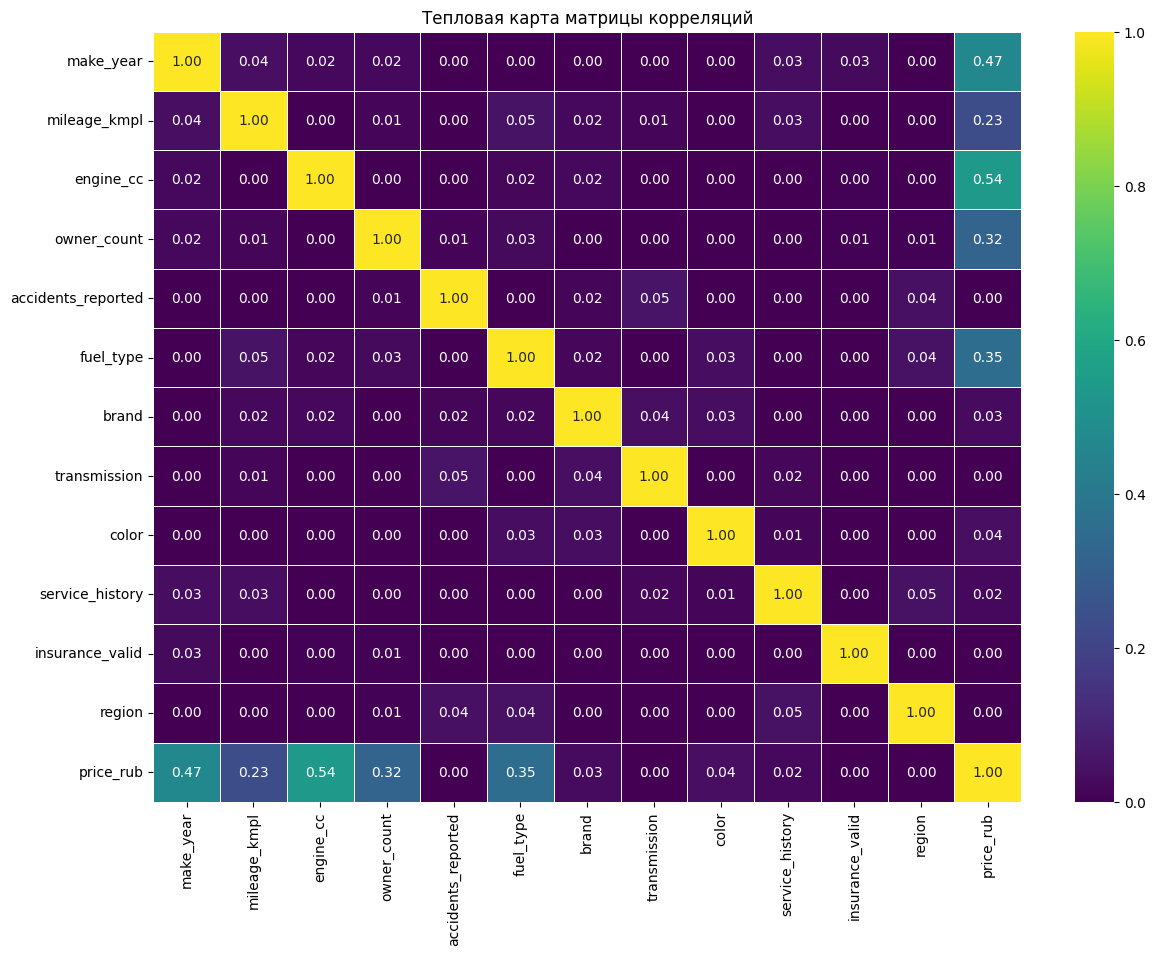

In [128]:
plot_corr_matrix(corr_matrix)

In [129]:
corr_with_target(corr_matrix=corr_matrix, target_col_name=target_col)

price_rub             1.000000
engine_cc             0.539546
make_year             0.466239
fuel_type             0.354523
owner_count           0.316419
mileage_kmpl          0.233398
color                 0.035179
brand                 0.028212
service_history       0.022291
accidents_reported    0.000000
transmission          0.000000
insurance_valid       0.000000
region                0.000000
Name: price_rub, dtype: float64

Анализ:
- наиболее сильная связь таргета с:
    - engine_cc (Объём двигателя) - предположительно, чем больше объем, тем дороже авто
    - make_year (Год выпуска) - предположительно, чем старше машина, тем она дешевле 
    - fuel_type (Тип топлива) - экономичность влияет на стоимость 
    - owner_count (Кол-во владельцев) - предположительно, чем больше было владельцев, тем больше просадка по цене

- По корреляции практически нет связи с:
    - accidents_reported - кол-во ДТП. Это довольно странно, на первый взгляд. Ведь кол-во ДТП должно существенно снижать ценник
    - transmission - коробка передач влияет на комфорт, но, видимо, не на цену
    - insurance_valid - наличие действующей страховки, предположительно, не такой важный фактор при формировании цены
    - region - от региона цена мало зависит 

Замечание:
- как упоминалось в ТЗ, связи могут быть нелинейными и корреляционный анализ может не отражать сложные, скрытые зависимости в данных

### Итог по ИАД

#### Общая информация:
- тренировочный датасет состоит из 8000 объектов
- 7 категориальных и 5 числовых признаков + таргет числовой
- пропусков и дублей нет

#### Распределения:

Таргет:
- распределение таргета симметричное (можно приблизить усеченным слева нормальным распределением)
- в правом хвосте распределения есть малочисленные выбросы 
- на левой границе можно отметить пороговое значение 95000 (подозрительно ровная сумма!), ниже которого значений нет. Возможно, это фиксированная нижняя цена для всех покупаемых на перепродажу авто. 

Количественные признаки:
- make_year	(Год выпуска) - распределение равномерное.
- mileage_kmpl	(Пробег (км)) - симметричное распределение с явной минимальной границей в 5.0км. Есть малочисленные экстремальные значения на правом хвосте
- engine_cc	(Объём двигателя (в кубических см)) - дискретный набор стандартных по объему двигателя значений. Среди дискретных значений распределение равномерное. Чаще встречаются двигателя объемом до 2000 куб. см.
- owner_count	(Количество владельцев по ПТС) - от 1 до 5 целые значения. Распределение равномерное
- accidents_reported	(Количество зафиксированных ДТП) - от 0 до 5 целые значения. Распределение экспоненциально убывает. Чтобы усилить связь большого кол-ва ДТП с целевую переменной, стоит рассмотреть преобразование возведения в степень.


Категориальные:
- brand	(Марка автомобиля) - в лидерах Nissan, наименне пополярен Ford. По количеству все марки в пределах 10% около среднего.
- region (Макрорегион РФ, в котором продаётся автомобиль) - наиболее популярный ЮГ, наименее - Сибирь. Распределение в в пределах 10% около среднего. 
- color	(Цвет автомобиля) - распределение равномерное (черные и белые чаще встречаются, чем синие и серебрянные, но разница несущественная)
- insurance_valid	(Действительна ли страховка) - существенное преобладание авто с действующей на момент сделки страховки. Разница в 4 раза
- service_history	(Наличие сервисной книжки) - преобладают значения с полной историей, с частичной исторей меньше в ~1.5 раза, без истории меньше в ~2.5 раза
-  transmission	(Тип коробки передач) - механики в 1.5 раза больше, чем автомата
- fuel_type	(Тип топлива) - бензиновые двигателей на 20% больше, чем дизеля. Электрокары малочисленны - более чем в 4 раза меньше, чем остальных видов.

#### Корреляционный анализ:

- наиболее сильная связь таргета с:
    - engine_cc (Объём двигателя) - предположительно, чем больше объем, тем дороже авто
    - make_year (Год выпуска) - предположительно, чем старше машина, тем она дешевле 
    - fuel_type (Тип топлива) - экономичность влияет на стоимость 
    - owner_count (Кол-во владельцев) - предположительно, чем больше было владельцев, тем больше просадка по цене

- По корреляции практически нет связи с:
    - accidents_reported - кол-во ДТП. Это довольно странно, на первый взгляд. Ведь кол-во ДТП должно существенно снижать ценник
    - transmission - коробка передач влияет на комфорт, но, предположительно, не на цену
    - insurance_valid - наличие действующей страховки, предположительно, не такой важный фактор при формировании цены
    - region - от региона цена, предположительно, мало зависит 

Замечание:
- связи могут быть нелинейными и корреляционный анализ может не отражать сложные, скрытые зависимости в данных


#### Выводы
- для количественных данных с симметричными распределениями можно рассмотреть фильтрацию экстремальных внутри пайплайна предобработки данных
- для дискретных данных, которые показали низкую корреляцию с таргетом можно попробовать применить преобразование признаков: возведение в степень для accidents_reported, например 

---
## 3. Предобработка

- Подготовьте признаки.
- Сформируйте одинаковые обучающие и валидационные выборки для всех трёх библиотек.
- Используйте файл ds_s16_test_data.csv как отложенную тестовую выборку.

In [159]:
for col in cat_cols_feat:
	# приведение всех категориальных признаков к pd.categorical
	df_train[col] = df_train[col].astype('category')


#### Разделение на выборки

In [160]:
X_train_val = df_train.drop(columns='price_rub')
y_train_val = pd.Series(df_train['price_rub'], name='target')
display(X_train_val.head(), y_train_val)

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,brand,transmission,color,service_history,accidents_reported,insurance_valid,region,accidents_reported_pow2,accidents_reported_pow3
0,2002,9.70,1800,Diesel,2,Hyundai,Manual,Silver,Partial,0,No,Урал,0,2.718282
1,2004,16.10,1500,Diesel,3,Hyundai,Manual,Black,Unknown,0,No,Москва,0,2.718282
2,2005,10.51,5000,Diesel,2,Ford,Manual,Gray,Full,0,No,Юг,0,2.718282
3,2019,14.27,2000,Petrol,5,Hyundai,Manual,White,Full,1,Yes,Дальний Восток,1,7.389056
4,2015,21.72,1000,Petrol,1,Toyota,Automatic,Black,Full,0,Yes,Сибирь,0,2.718282


0       242073
1       426029
2       727050
3       753168
4       733390
         ...  
7995    993550
7996    487962
7997    808630
7998    642222
7999    622646
Name: target, Length: 8000, dtype: int64

In [161]:
# train 50% и validate 50%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.5,
    shuffle=True,
    random_state=RANDOM_SEED
)

### Пайплайн предобработки

In [153]:
def select_cat(X):
    return X.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()

def to_categorical(X):
    """Приведение к pd.categorical"""
    return X.astype('category')


In [ ]:
def create_prepocessing_pipeline():
    """
    Создание пайплайна предобработки данных.
    """

    # преобразование типов для категориальных данных
    to_categorical_transformer = FunctionTransformer(to_categorical)

    transformers=[
        ('to_categorical', to_categorical_transformer, select_cat)
    ]

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='passthrough'
    )

    result_pipeline = [
        ('prep', preprocessor)
    ]

    return Pipeline(result_pipeline)

---
## 4. Обучение моделей в разных библиотеках

Проведите первый раунд «турнира библиотек» на базовых настройках.

Обучите три модели: XGBoost, CatBoost и LightGBM.

Сравните их базовые метрики (RMSE, MAE, R²).

Основаная метрика в турнире: MAE (Mean Absolute Error)

Сравните их также по бизнес-метрикам:
- Overpricing Rate — доля случаев, когда модель завысила цену более чем на 20%.
- Underpricing Loss — суммарная потеря, когда цена была занижена более чем на 20%.

In [201]:
def calc_metrics(y_true, y_pred, model_name: str):
    # 1
    # Рассчитываем относительное отклонение
    error_ratio = (y_pred - y_true) / y_true
    # Считаем долю тех, где отклонение выше 20%
    overpricing_rate = (error_ratio > 0.20).mean()

    # 2
    # Находим маску (фильтр) для случаев занижения цены на 20%+
    under_mask = error_ratio < -0.20
    # Суммируем разницу между реальной ценой и предсказанием для этих случаев
    underpricing_loss = (y_true[under_mask] - y_pred[under_mask]).sum()

    # 3
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    result_df = pd.DataFrame(
        {   'model_name': model_name,
            'overpricing_rate': overpricing_rate,
            'underpricing_loss': underpricing_loss,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }, index=[0]
    )
    return result_df

### Обучение базовой модели XGBoost

In [202]:
def plot_xgb_model_learning_curve(xgb_model):
    # Достаём значения метрики rmse на каждой итерации обучения
    results = xgb_model.evals_result()

    epochs = len(results['validation_0']['rmse'])
    x = range(epochs)

    # Строим график
    plt.plot(x, results['validation_0']['rmse'], label='RMSE на обучающей выборке')
    plt.plot(x, results['validation_1']['rmse'], label='RMSE на валидационной выборке')
    plt.xlabel('Кол-во итераций (n_estimators)')
    plt.ylabel('Значение RMSE')
    plt.title('График зависимости значения RMSE на обучающей/валидационной выборках')
    plt.legend()
    plt.grid(True)
    plt.show()

In [203]:
xgb_model_base = XGBRegressor(
    random_state=RANDOM_SEED, 
    enable_categorical=True,
    learning_rate=0.3,
    eval_metric="rmse",
    n_estimators=100,
    n_jobs=-1,
    early_stopping_rounds=20
)

In [204]:
# Обучаем модель с eval_set
xgb_model_base.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=20,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.3, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

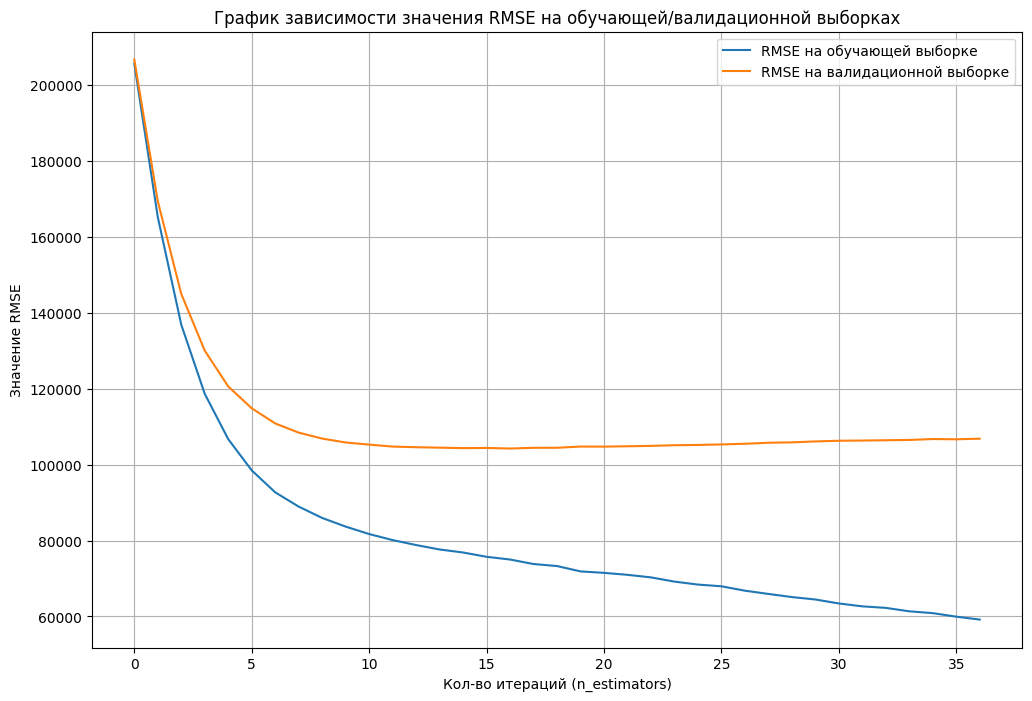

In [209]:
plot_xgb_model_learning_curve(xgb_model_base)

Анализ:
- без ранней остановки бустинг существенно переобучается: на validate ошибка перестает падать после 10ой итерации

In [210]:
# метрики на validate
y_val_pred_xgb_model_base = xgb_model_base.predict(X_val)

In [211]:
xgb_model_base_metrics = calc_metrics(
    y_val_pred_xgb_model_base, y_val, model_name='xgb_model_base'
)
xgb_model_base_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,xgb_model_base,0.1185,7.059278e+07,104218.921875,83770.351562,0.808853


### Обучение базовой модели LightGBM

In [216]:
lgbm_base = LGBMRegressor(
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

In [217]:
lgbm_base.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols_feat, 
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 14
[LightGBM] [Info] Start training from score 678248.009500


LGBMRegressor(n_jobs=-1, random_state=42)

In [ ]:
# предсказания на validate
y_pred_val_lgbm_base = lgbm_base.predict(X_val)

In [219]:
lgbm_base_metrics = calc_metrics(
    y_pred_val_lgbm_base, y_val, model_name='lgbm_base'
)
lgbm_base_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,lgbm_base,0.1135,6.613253e+07,101019.004652,80934.920359,0.825719


### Обучение базовой модели CatBoost

In [222]:
# Инициализируем CatBoostRegressor
cbr_model_base = CatBoostRegressor(
    random_state=RANDOM_SEED, 
    iterations=3000,               # максимум итераций
    l2_leaf_reg=1.0,               # регуляризация
    bootstrap_type="Bayesian",     # стохастический бутстрап
    bagging_temperature=0.4,       # уровень стохастики
    early_stopping_rounds=200,     # остановка при отсутствии улучшения
    use_best_model=True,           # сохранить лучшую модель
)

In [223]:
cbr_model_base.fit(
    X_train,
    y_train,
    cat_features=cat_cols_feat,
    eval_set=(X_val, y_val),
    verbose=200
)

0:	learn: 260581.4100753	test: 258141.8283000	best: 258141.8283000 (0)	total: 4.3ms	remaining: 12.9s
200:	learn: 91954.7065877	test: 98923.6189202	best: 98923.6189202 (200)	total: 344ms	remaining: 4.79s
400:	learn: 87417.8477307	test: 97855.6457862	best: 97855.6457862 (400)	total: 660ms	remaining: 4.28s
600:	learn: 83727.6420724	test: 97846.6530582	best: 97815.8753525 (460)	total: 974ms	remaining: 3.89s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 97815.87535
bestIteration = 460

Shrink model to first 461 iterations.


CatBoostRegressor(bagging_temperature=0.4, bootstrap_type='Bayesian', early_stopping_rounds=200, iterations=3000, l2_leaf_reg=1.0, loss_function='RMSE', random_state=42, use_best_model=True)

In [225]:
# предсказания на validate
y_pred_val_cbr_model_base = cbr_model_base.predict(X_val)

In [226]:
cbr_base_metrics = calc_metrics(
    y_pred_val_cbr_model_base, y_val, model_name='cbr_model_base'
)
cbr_base_metrics

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,cbr_model_base,0.104,6.127636e+07,97815.875353,78263.016332,0.835764


In [228]:
results = pd.concat(
    [cbr_base_metrics, lgbm_base_metrics, xgb_model_base_metrics],
).sort_values(by='mae')
results

,model_name,overpricing_rate,underpricing_loss,rmse,mae,r2
0,cbr_model_base,0.1040,6.127636e+07,97815.875353,78263.016332,0.835764
0,lgbm_base,0.1135,6.613253e+07,101019.004652,80934.920359,0.825719
0,xgb_model_base,0.1185,7.059278e+07,104218.921875,83770.351562,0.808853


Анализ:
- базовые модели XGBRegressor, CatBoostRegressor, LGBMRegressor показывают схожие результаты по ключевым метрикам на валидационной выборке 
- CatBoostRegressor пока лидирует по всем показателям, в том числе по ключевому MAE 

---
## 5. Работа с параметрами модели (Тюнинг)

Теперь нужно выжать максимум из каждого алгоритма с помощью подбора параметров через Optuna. Чтобы ограничить вариативность и сфокусироваться на главном, используйте следующие диапазоны: 

1. Общая сетка для всех моделей: 
- Скорость обучения ( learning_rate / eta ): от 0.01 до 0.1, log=True.
- Глубина дерева ( max_depth / depth ): от 3 до 10.
- Количество итераций ( n_estimators / iterations ): зафиксируйте в диапазоне 500–2000.

Специфические параметры (регуляризация): 
- Для XGBoost: добавьте параметры gamma от 1e-8 до 1.0 и reg_lambda / reg_alpha от 1e-8 до 10.0.
- Для CatBoost: используйте l2_leaf_reg от 1 до 10.
- Для LightGBM: добавьте num_leaves от 20 до 256 и min_child_samples от 5 до 100; reg_alpha и reg_lambda от 1e-8 до 1.0.

Не забудьте "random_seed": 42 и MAE .

Найдите лучшую версию модели внутри каждой библиотеки.


---
## 6. Интерпретация и бизнес-анализ
Разберитесь, что происходит внутри «чёрного ящика» и как модель ведёт себя с точки зрения бизнеса:

1. Важность признаков (SHAP)
Для Топ-3 моделей проведите анализ важности признаков с помощью SHAP.
Сформируйте Топ-5 признаков, которые сильнее всего влияют на стоимость авто.

2. Анализ ошибок через over и under-pricing
Используйте введённые метрики Overpricing Rate и Underpricing Loss:
рассчитайте долю завышений и недооценок для каждой модели;
сравните модели не только по MAE/RMSE, но и по бизнес-рискам.

3. Склонность к завышению и занижению по маркам
Проанализируйте, какие марки авто и регионы чаще «страдают» от систематического завышения или занижения цены: overpricing rate и underpricing loss.

---
## 7. Финальная проверка
Выполните финальную оценку лучшей оптимизированной модели на ds_s16_test_data.csv.

Посмотрите метрики на валидационной выборке и на финальном тесте. 

Если результаты близки (разница менее 5–10%), значит, модель стабильна и не переобучилась.

---
## 8. Описание выводов и финальный вердикт

Подготовьте краткую аналитическую записку в конце ноутбука для Артёма (CEO) и Юли (Head of Data).

Какая библиотека дала лучший результат с точки зрения бизнес-метрик (Overpricing Rate / Underpricing Loss) и стандартных метрик качества.

Сделайте итоговую рекомендацию: какую библиотеку и с какими гиперпараметрами стоит внедрять в мобильное приложение AutoValue AI.